In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 
 
ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'processed'/'hospital_clean.csv')

print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))

print('\nReadmission distribution:')
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(3)*100)

Shape: (99493, 53)
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
g

In [2]:
df_risk = df.copy()

# Score each risk factor (points system)
df_risk['score'] = 0

# Prior inpatient visits (strongest predictor)
df_risk['score'] += df_risk['number_inpatient'].clip(0, 5) * 3

# Number of medications
df_risk['score'] += (df_risk['num_medications'] > 15).astype(int) * 2

# Number of diagnoses
df_risk['score'] += (df_risk['number_diagnoses'] > 7).astype(int) * 2

# Prior emergency visits
df_risk['score'] += df_risk['number_emergency'].clip(0, 3) * 2

# Age (older patients higher risk)
df_risk['score'] += (df_risk['age_numeric'] >= 70).astype(int) * 2

# Long length of stay
df_risk['score'] += (df_risk['time_in_hospital'] >= 7).astype(int) * 1

# Assign risk tier
def risk_tier(score):
    if score >= 12:  return 'Critical Risk'
    elif score >= 8: return 'High Risk'
    elif score >= 4: return 'Medium Risk'
    else:            return 'Low Risk'

df_risk['risk_tier'] = df_risk['score'].apply(risk_tier)

# Validate — check actual readmission rate by tier
validation = df_risk.groupby('risk_tier').agg(
    patients           = ('readmitted_30', 'count'),
    actual_readmission = ('readmitted_30', 'mean')
).round(4)
validation['actual_readmission_pct'] = (validation['actual_readmission'] * 100).round(1)
print(validation.sort_values('actual_readmission', ascending=False))

df_risk.to_csv('../data/processed/patients_risk_scored.csv', index=False)
print('Risk-scored patients saved')


               patients  actual_readmission  actual_readmission_pct
risk_tier                                                          
Critical Risk      9004              0.2366                    23.7
High Risk         12790              0.1572                    15.7
Medium Risk       43229              0.1056                    10.6
Low Risk          34470              0.0715                     7.2
Risk-scored patients saved


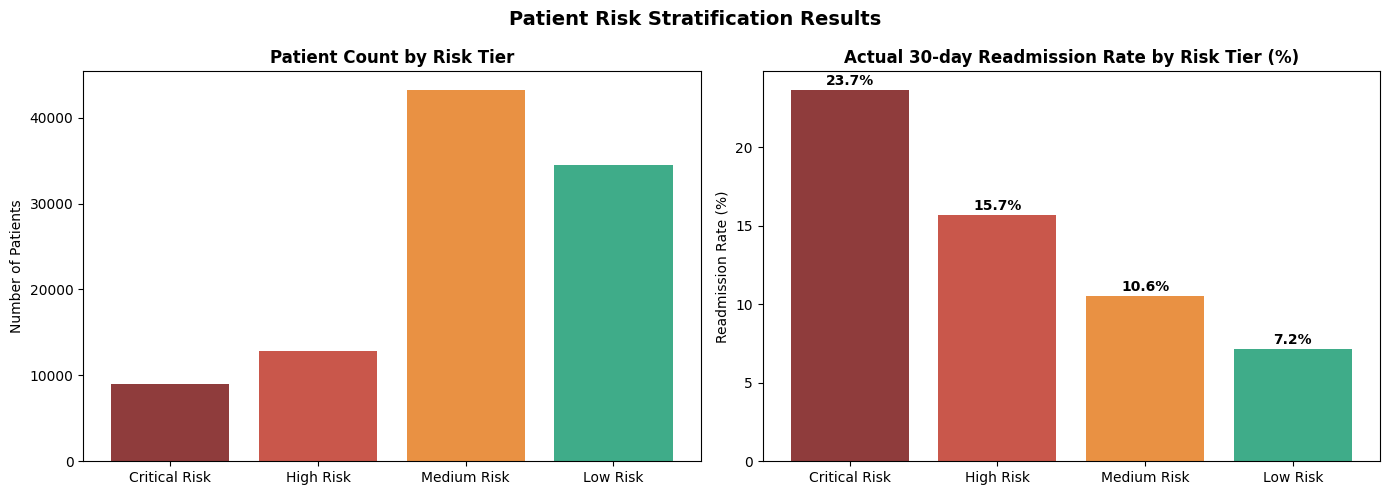

In [3]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

#Risk tier distribution
tier_counts = df_risk['risk_tier'].value_counts()
tier_order  = ['Critical Risk','High Risk','Medium Risk','Low Risk']
tier_colors = ['#7B1A1A','#C0392B','#E67E22','#1D9E75']
axes[0].bar(
    [t for t in tier_order if t in tier_counts.index],
    [tier_counts.get(t,0) for t in tier_order if t in tier_counts.index],
    color=[c for t,c in zip(tier_order, tier_colors) if t in tier_counts.index],
    alpha=0.85
)
axes[0].set_title('Patient Count by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Patients')

# Actual readmission rate by tier
readm_by_tier = df_risk.groupby('risk_tier')['readmitted_30'].mean() * 100
readm_by_tier = readm_by_tier.reindex([t for t in tier_order if t in readm_by_tier.index])
axes[1].bar(readm_by_tier.index, readm_by_tier.values,
            color=[c for t,c in zip(tier_order, tier_colors) if t in readm_by_tier.index],
            alpha=0.85)
axes[1].set_title('Actual 30-day Readmission Rate by Risk Tier (%)', fontweight='bold')
axes[1].set_ylabel('Readmission Rate (%)')
for i, v in enumerate(readm_by_tier.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Patient Risk Stratification Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/risk_stratification.png', dpi=150, bbox_inches='tight')
plt.show()
